**Análisis Descriptivo sobre el Dataset de Transporte Público de Chicago**

In [1]:
# MUY IMPORTANTE: SI DECIDES EJECUTAR ESTE NOTEBOOK EN VSCODE, EN LUGAR DE GOOGLE COLAB,
# DEBERÁS DESCOMENTAR ESTAS DOS INSTRUCCIONES PARA EVITAR ERRORES:

# import ssl

# ssl._create_default_https_context = ssl._create_unverified_context

In [2]:
# Carga del dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar datos en dataframe
url = "https://raw.githubusercontent.com/gakudo-ai/open-datasets/main/CTA_-_Ridership_-_Daily_Boarding_Totals.csv"
df = pd.read_csv(url, parse_dates=["service_date"])

In [3]:
# 1. PREPROCESAMIENTO BÁSICO E INGENIERÍA DE CARACTERÍSTICAS ---
# Eliminar duplicados
df = df.drop_duplicates()

# Establecer columna de fecha como índice
df = df.set_index("service_date").sort_index()

# Extraer variables temporales
df["day_of_week"] = df.index.day_name()
df["year"] = df.index.year
df["month"] = df.index.month

# Lista de días en orden (sera útil después en algunas visualizaciones)
dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

**Pregunta de análisis 1:** ¿Existen patrones estacionales o diferencias significativas entre años en el número promedio de pasajeros por mes?

**Utilidad:** mejora en la planificación de recursos (vehículos, personal) según temporada, detección de caídas o crecimientos año tras año.

<Figure size 1400x1200 with 0 Axes>

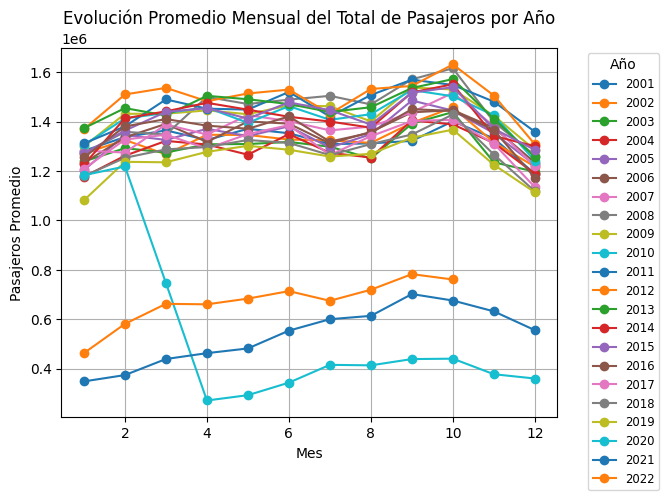

In [4]:
monthly_avg = df.groupby(["year", "month"])["total_rides"].mean().unstack(level=0)

plt.figure(figsize=(14, 12))
monthly_avg.plot(marker='o')
plt.title("Evolución Promedio Mensual del Total de Pasajeros por Año")
plt.xlabel("Mes")
plt.ylabel("Pasajeros Promedio")
plt.grid(True)
plt.legend(title="Año", fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

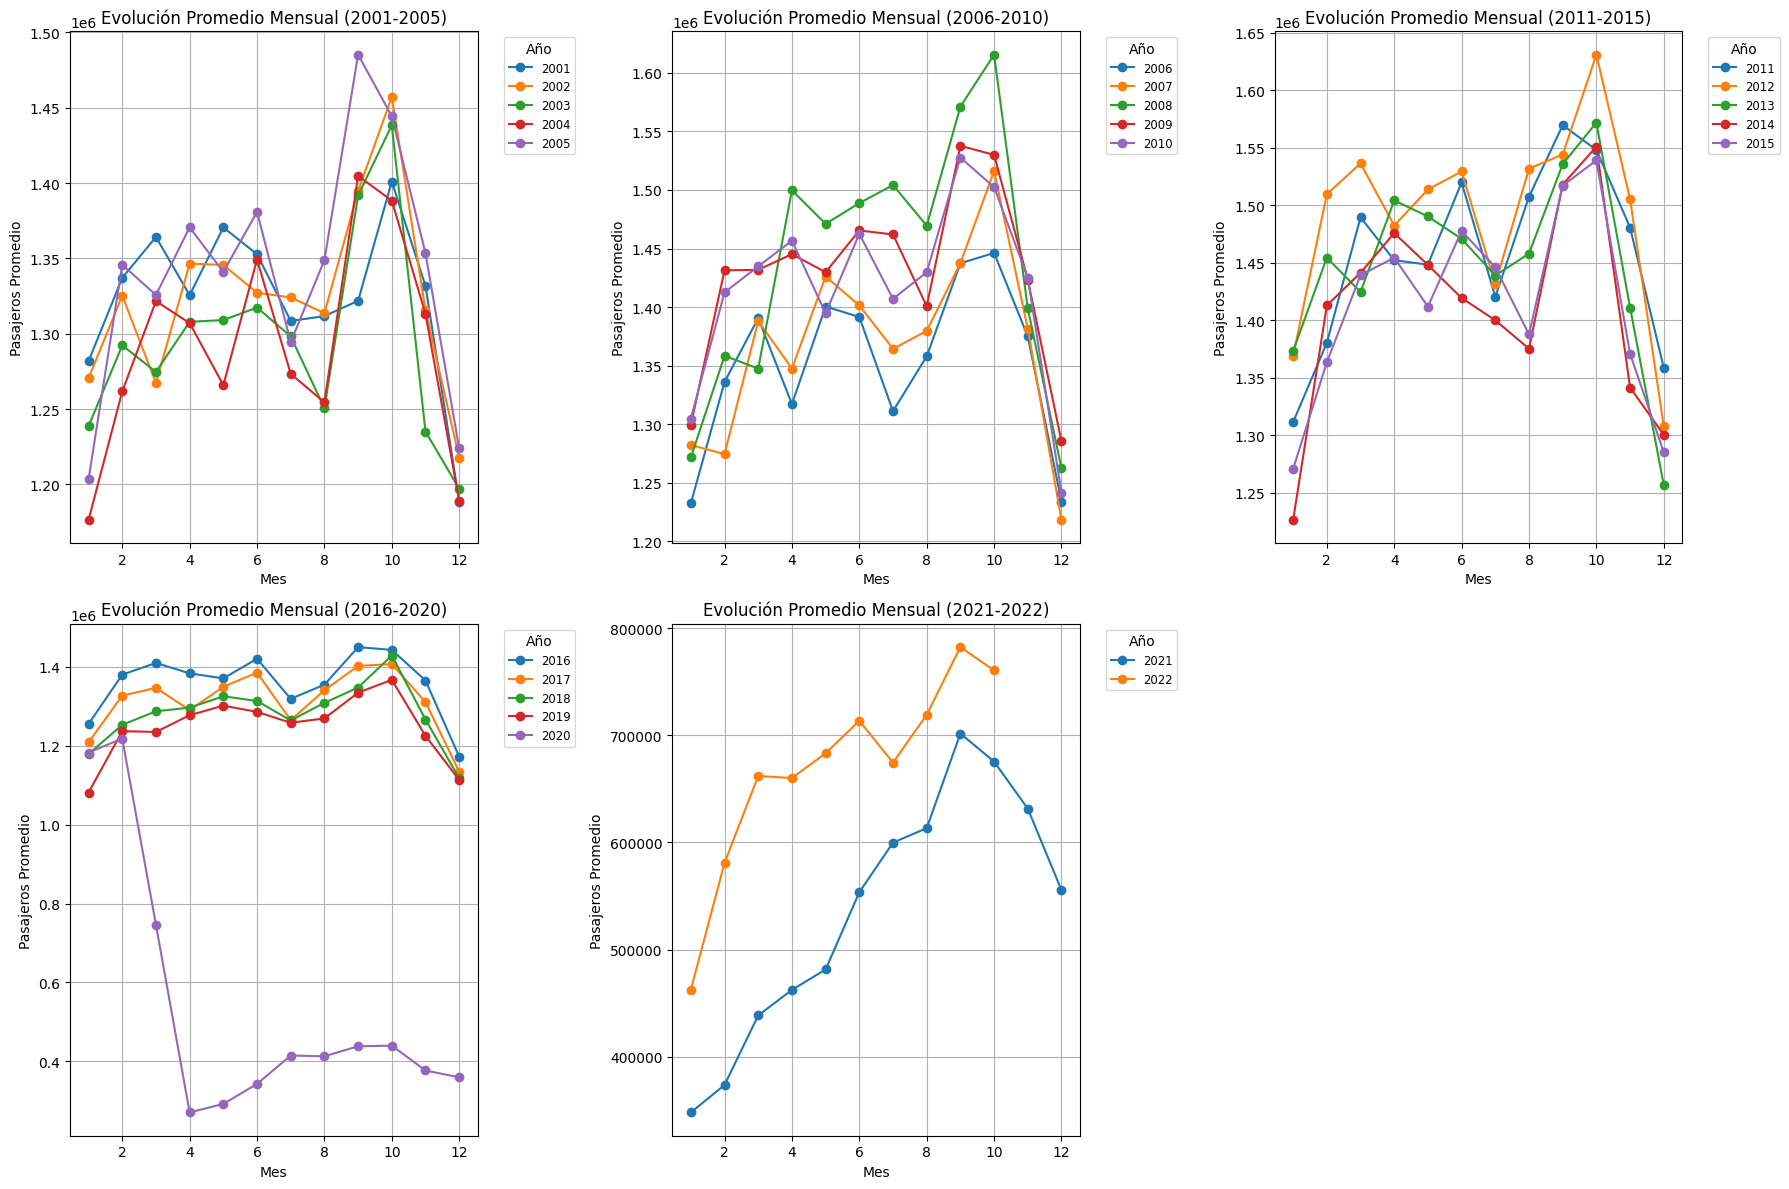

In [5]:
# Dado que el gráfico anterior está muy sobrecargado, haremos varios para tramos de 5 años

year_ranges = [(2001, 2005), (2006, 2010), (2011, 2015), (2016, 2020), (2021, 2022)]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten() # Flatten the 2x3 grid into a 1D array for easy iteration

for i, (start_year, end_year) in enumerate(year_ranges):
    ax = axes[i]
    # Selección de años dentro del subintervalo actual
    years_to_plot = [year for year in monthly_avg.columns if start_year <= year <= end_year]
    monthly_avg[years_to_plot].plot(marker='o', ax=ax)
    ax.set_title(f"Evolución Promedio Mensual ({start_year}-{end_year})")
    ax.set_xlabel("Mes")
    ax.set_ylabel("Pasajeros Promedio")
    ax.grid(True)
    ax.legend(title="Año", fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')

# Como nos sobra un hueco en el "lienzo" de 3x2, aseguramos de que se quede en blanco y sin ejes vacíos
axes[-1].axis('off')

plt.tight_layout()
plt.show()

**Pregunta de análisis 2:** ¿Cómo varía a lo largo del tiempo la proporción de pasajeros que utilizan el autobús frente al tren? ¿Existen cambios estructurales/importantes en las preferencias de los usuarios?

**Utilidad:** conocer posibles cambios en la demanda relativa entre medios de transporte puede ayudar a tomar mejores decisiones de inversión, mantenimiento o marketing por cada tipo de transporte.

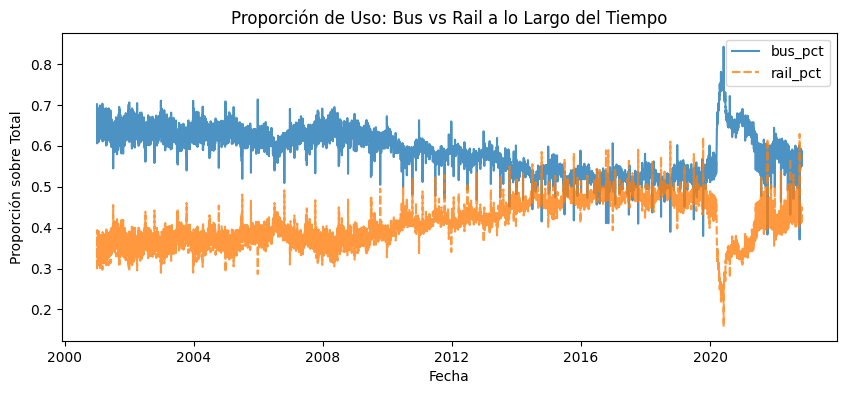

In [6]:
# Análisis proporcional: compararemos las proporciones relativas de pasajeros de bus vs. tren
transport_df = df[["bus", "rail_boardings", "total_rides"]].copy()
transport_df["bus_pct"] = df["bus"] / df["total_rides"]
transport_df["rail_pct"] = df["rail_boardings"] / df["total_rides"]
# Aquí tenemos la suerte de disponer del atributo "total_rides", pero si no lo tuvieramos
# las proporciones relativas las podemos calcular igualmente, diviviendo entre la suma de ambos atributos.

plt.figure(figsize=(10, 4))
sns.lineplot(data=transport_df[["bus_pct", "rail_pct"]], alpha=0.8)
plt.title("Proporción de Uso: Bus vs Rail a lo Largo del Tiempo")
plt.ylabel("Proporción sobre Total")
plt.xlabel("Fecha")
plt.show()

**Pregunta de análisis 3:** ¿Qué días de la semana presentan mayor y menor volumen de pasajeros, y cuánta variabilidad existe en cada paso?

**Utilidad:** Optimizar frecuencia de vehículos y gestión de personal por día. También sirve para anticipar días con mayor demanda y planificar mantenimiento para días en los que se espera menos flujo de pasajeros.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Agregar los días de la semana (DOW: Day Of Week) para obtener la media y desviación estándar por día de la semana
# para el atributo "total_rides"
dow_avg = df.groupby("day_of_week")["total_rides"].agg(["mean", "std"]).reindex(dias)
dow_avg

,mean,std
day_of_week,,
Monday,1.387960e+06,400006.586740
Tuesday,1.486008e+06,372988.707096
Wednesday,1.483334e+06,373022.635480
Thursday,1.467726e+06,392422.522752
Friday,1.468932e+06,374545.294922
Saturday,9.123752e+05,218739.857184
Sunday,6.555369e+05,162651.281638


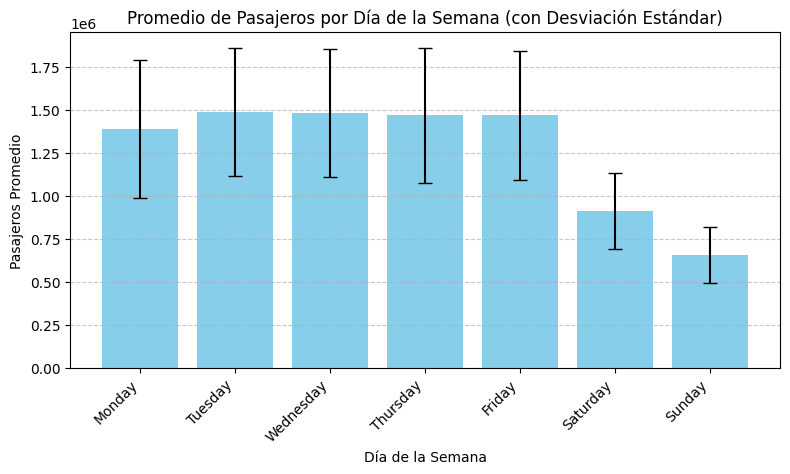

In [8]:
plt.figure(figsize=(8, 5))

# Obtener los nombre de los días de la semana para el eje X
x_pos = np.arange(len(dow_avg.index))
# x_pos contiene posiciones del 0 al 6

plt.bar(dias, dow_avg["mean"], yerr=dow_avg["std"], capsize=5, color='skyblue')
# 'Yerr' añade "márgenes de error" a cada barra del gráfico.

# Set the x-axis labels
plt.xticks(x_pos, dow_avg.index, rotation=45, ha='right') # También puedes usar la lista "dias" para el 2o argumento
plt.title("Promedio de Pasajeros por Día de la Semana (con Desviación Estándar)")
plt.ylabel("Pasajeros Promedio")
plt.xlabel("Día de la Semana")
plt.grid(axis='y', linestyle='--', alpha=0.7) # Añadir cuadrícula horizontal de fondo

plt.tight_layout() # Ajustar para evitar solapamientos entre elementos del gráfico
plt.show()

**Pregunta de análisis 4:** ¿Cómo ha impactado la pandemia de COVID-19 en el número diario de pasajeros? ¿Se ha recuperado la demanda a los niveles previos?

**Utilidad:** comprender la magnitud del impacto de un fenómeno externo del mundo real, y evaluar si se necesitan nuevas estrategias como políticas de incentivo de uso del transporte público de forma segura, campañas o ajuste operativos que se adecúen a los cambios.

/tmp/ipykernel_8797/2412942539.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="era", y="total_rides", data=df, palette="Set2")


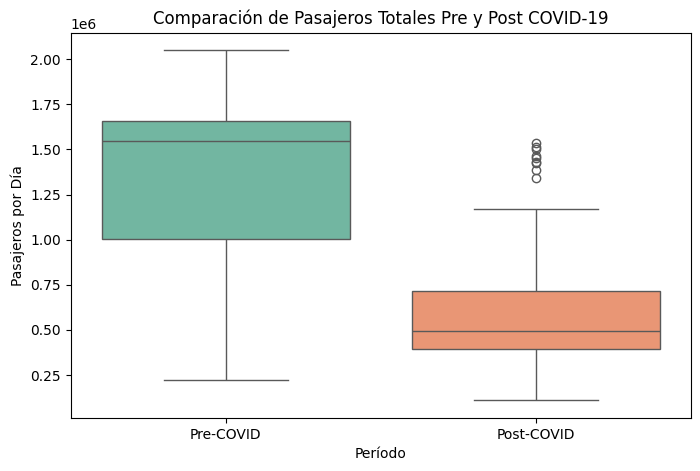

In [9]:
# Creación de un atributo categórico "era", con dos posibles valores: pre-covid y post-covid
df["era"] = ["Pre-COVID" if date < pd.Timestamp("2020-03-01") else "Post-COVID" for date in df.index]

plt.figure(figsize=(8, 5))
sns.boxplot(x="era", y="total_rides", data=df, palette="Set2")
plt.title("Comparación de Pasajeros Totales Pre y Post COVID-19")
plt.ylabel("Pasajeros por Día")
plt.xlabel("Período")
plt.show()

**Pregunta de análisis 5:** ¿Qué tendencia general sigue el uso del transporte público? ¿Se observan momentos de crecimiento, caída o estabilización a lo largo del tiempo?

**Utilidad:** monitorización de cambios a largo plazo, detección de efectos de decisiones pasadas (subida de tarifas, cambios de rutas) o eventos externos.

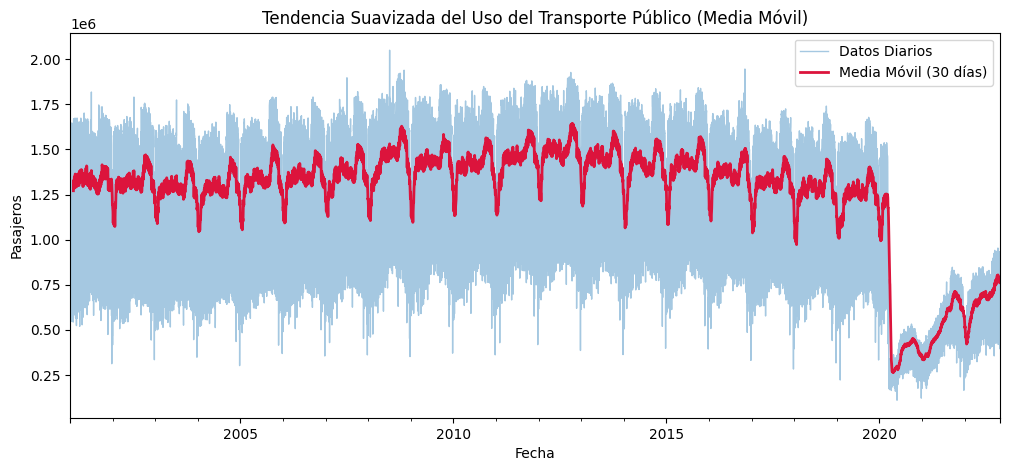

In [10]:
# Cálculo de media móvil (o media deslizante, rolling mean):
# Promedio calculado tomando los últimos 30 días consecutivos al día actual
# Es una ventana de amplitud 30, que se va desplazando.
# Este tipo de estadístico permite suavizar los datos, especialmente altibajos muy bruscos.
# Lo cual ayuda a ver la tendencia general y "a alto nivel" de forma más clara
df["rolling_mean_30"] = df["total_rides"].rolling(window=30).mean()

plt.figure(figsize=(12, 5))
df["total_rides"].plot(alpha=0.4, label="Datos Diarios", linewidth=1)
df["rolling_mean_30"].plot(label="Media Móvil (30 días)", linewidth=2, color="crimson")
plt.title("Tendencia Suavizada del Uso del Transporte Público (Media Móvil)")
plt.ylabel("Pasajeros")
plt.xlabel("Fecha")
plt.legend()
plt.show()


En el anterior gráfico se utiliza una **media móvil de 30 días** (rolling average) para mostrar la tendencia del número de pasajeros, eliminando las variaciones diarias y permitiendo identificar cambios sostenidos en el tiempo.

En el siguiente ejemplo hacemos zoom y ponemos la lente en un solo año, lo que nos enseñará que dependiendo de cuán de cerca o de lejos observamos los datos, podemos encontrar patrones y tendencias diferentes a distintos niveles.

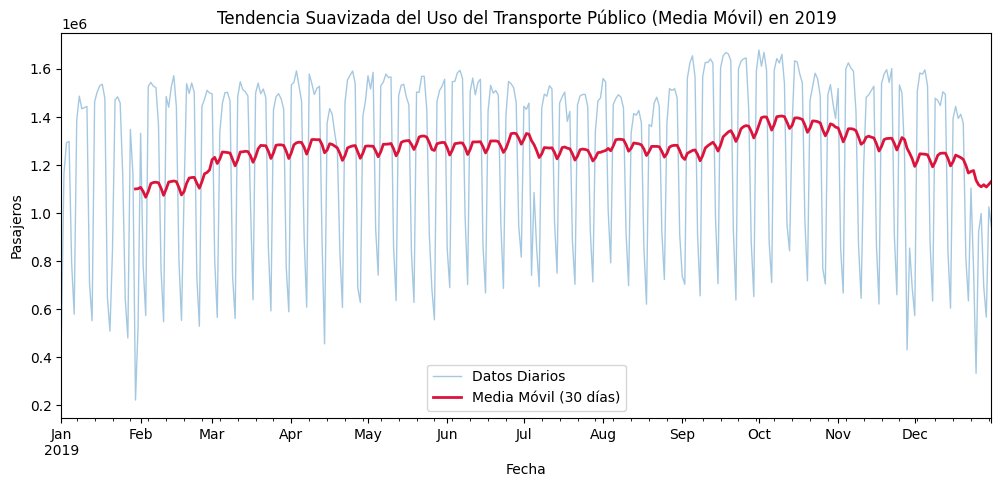

In [11]:
# Cálculo de media móvil (o media deslizante, rolling mean):
# Promedio calculado tomando los últimos 30 días consecutivos al día actual
# Es una ventana de amplitud 30, que se va desplazando.
# Este tipo de estadístico permite suavizar los datos, especialmente altibajos muy bruscos.
# Lo cual ayuda a ver la tendencia general y "a alto nivel" de forma más clara

# Filter the DataFrame for the year 2019
df_2019 = df[df.index.year == 2019].copy()

df_2019["rolling_mean_30"] = df_2019["total_rides"].rolling(window=30).mean()

plt.figure(figsize=(12, 5))
df_2019["total_rides"].plot(alpha=0.4, label="Datos Diarios", linewidth=1)
df_2019["rolling_mean_30"].plot(label="Media Móvil (30 días)", linewidth=2, color="crimson")
plt.title("Tendencia Suavizada del Uso del Transporte Público (Media Móvil) en 2019")
plt.ylabel("Pasajeros")
plt.xlabel("Fecha")
plt.legend()
plt.show()